# 9. PyTorch Model Deployment

## Reference Material
https://www.learnpytorch.io/09_pytorch_model_deployment/

https://github.com/mrdbourke/pytorch-deep-learning

https://www.amazon.com/Designing-Machine-Learning-Systems-Production-Ready/dp/1098107969

https://madewithml.com/#mlops

https://www.mlebook.com/wiki/doku.php

https://fullstackdeeplearning.com/

## Deployment considerations


Questions to ask
1. Ideal ML model deployment scenario?
  * Works every time? | Start here and work backwards
  * Speed of light (fast)
2. Where's the model going to go?
  * On-device (edge)
  * Cloud
3. How's the model going to function?
  * Online (real-time)
  * Offline (batch)

Questions 2 and 3 can mix and match

##**How's the model going to function?**

For our FoodVision Mini app, we want real-time inference but training can be done in batch.

**Places/tools to help deploy machine learning models**
1. On-device (mobile/edge)
  * Google's MLKit
  * Apple's CoreML
2. Cloud
  * Google Cloud Vertex AI
  * AWS Sagemaker
  * Hugging Face with Gradio
  * Azure Machine Learning
3. General
  * Torchserve
  * FastAPI
  * Open Neural Network Exchange (ONNX)


## 0. Getting setup

In [2]:
import torch
import torchvision
import matplotlib.pyplot as plt
from torch import nn
from torchvision import transforms

In [3]:
!pip install torchinfo

  Using cached torchinfo-1.8.0-py3-none-any.whl.metadata (21 kB)
Using cached torchinfo-1.8.0-py3-none-any.whl (23 kB)



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from torchinfo import summary

In [5]:
# Setup device agnostic code
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
device

device(type='cuda')

## 1. Getting Data

The dataset we're going to use for deploying a FoodVision Mini model is..

Pizza, steak, sushi 20% dataset (a random 20% of Food101 dataset with pizza, steak, and sushi classes).

In [6]:
# Try to import the going_modular directory, download it from GitHub if it doesn't work
try:
    from going_modular.going_modular import data_setup, engine
except:
    # Get the going_modular scripts
    print("[INFO] Couldn't find going_modular scripts... downloading them from GitHub.")
    !git clone https://github.com/mrdbourke/pytorch-deep-learning
    !mv pytorch-deep-learning/going_modular .
    !rm -rf pytorch-deep-learning
    from going_modular.going_modular import data_setup, engine

[INFO] Couldn't find going_modular scripts... downloading them from GitHub.


Cloning into 'pytorch-deep-learning'...
Updating files:  46% (115/248)
Updating files:  47% (117/248)
Updating files:  48% (120/248)
Updating files:  49% (122/248)
Updating files:  50% (124/248)
Updating files:  51% (127/248)
Updating files:  52% (129/248)
Updating files:  53% (132/248)
Updating files:  54% (134/248)
Updating files:  55% (137/248)
Updating files:  56% (139/248)
Updating files:  57% (142/248)
Updating files:  58% (144/248)
Updating files:  59% (147/248)
Updating files:  60% (149/248)
Updating files:  61% (152/248)
Updating files:  62% (154/248)
Updating files:  63% (157/248)
Updating files:  64% (159/248)
Updating files:  65% (162/248)
Updating files:  66% (164/248)
Updating files:  67% (167/248)
Updating files:  68% (169/248)
Updating files:  69% (172/248)
Updating files:  70% (174/248)
Updating files:  71% (177/248)
Updating files:  72% (179/248)
Updating files:  73% (182/248)
Updating files:  74% (184/248)
Updating files:  75% (186/248)
Updating files:  76% (189/248)

ModuleNotFoundError: No module named 'going_modular'

In [7]:
# Download pizza, steak, sushi images from GitHub
import os
import zipfile

from pathlib import Path

import requests

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it...
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/refs/heads/main/data/pizza_steak_sushi_20_percent.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...")
        zip_ref.extractall(image_path)

    # Remove .zip file
    os.remove(data_path / "pizza_steak_sushi.zip")

Did not find data\pizza_steak_sushi directory, creating one...
Unzipping pizza, steak, sushi data...


In [8]:
# Download helper_functions.py from mrdbourke's github
with open("helper_functions.py", "wb") as f:
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/refs/heads/main/helper_functions.py")
    print("Downloading helper_functions.py..")
    f.write(request.content)

In [9]:
# Setup training and test paths
train_dir = image_path / "train"
test_dir = image_path / "test"

## 2. FoodVision Mini model deployment experiment outline
So far, our best feature extractor models are:
1. EffNetB2
2. ViT

We will be using the pizza, steak, and sushi 20 percent dataset to compare the two models and select the best one for deployment.


### 3 questions
1. What is my most ideal machine learning deployment scenario?
2. Where is my model going to go?
3. How is my model going to function?

**FoodVision Mini ideal use case:** A model that performs well and fast
1. Performs well: 95%+ accuracy
2. Fast: as close to real-time (or faster) as possible (30 FPS+ or 30ms latency)
    * Latency = time for prediction to take place

## 3. Creating an EffNetB2 feature extractor
Feature extractor = a term for transfer learning model that has its base layers frozen and output layers (or head layers) customized to a certain problem.

EffNetB3 pretrained model in PyTorch - https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.efficientnet_b3.html#torchvision.models.efficientnet_b3

### 3.1 Creating a function to make an EffNetB2 feature extractor model

In [129]:
import helper_functions
def create_effnetb2_model(num_classes:int=3, # dfault output classes = 3 (pizza, steak, sushi)
                          seed:int=42):
  """Returns transforms and classes for an effnetb2 model with default weights
  Args:
  num_classes (int) - number of classes in the model
  seed (int) - random seed to initialize the trainable layers with"""

  helper_functions.set_seeds(42)

  # 1. Setup pretrained EffnetB3  with weights
  weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
  effnetb2_model = torchvision.models.efficientnet_b2(weights=weights)

  # 2. Get EffNetB2 transforms
  effnetb2_transforms = weights.transforms()

  # 3. Freeze all layers in base mdoel
  for param in effnetb2_model.features.parameters():
    param.requires_grad=False

  # 4. Change classifier head with random seed for reproducibility
  torch.manual_seed(seed)
  effnetb2_model.classifier = nn.Sequential(
      nn.Dropout(p=0.3, inplace=True),
      nn.Linear(in_features=1408,
                out_features=num_classes)
  )
  return effnetb2_model, effnetb2_transforms

In [11]:
effnetb2, effnetb2_transforms = create_effnetb2_model()

In [12]:
summary(model=effnetb2,
        input_size=(1, 3, 224, 224),
        col_width=20,
        col_names=["input_size","output_size","num_params","trainable"],
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 3]               --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1408, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 1

### 3.2 Creating DataLoaders for EffNetB2

In [13]:
from going_modular.going_modular import data_setup
train_dataloader_effnetb2, test_dataloader_effnetb2, num_classes = data_setup.create_dataloaders(
    train_dir = train_dir,
    test_dir = test_dir,
    transform = effnetb2_transforms,
    batch_size=32
)

### 3.3 Training EffNetB2 feature extractor

In [14]:
# Setup Loss function and optimizer
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(params = effnetb2.parameters(),
                             lr = 0.001)

In [15]:
# Training function
helper_functions.set_seeds()


from going_modular.going_modular.engine import train
effnetb2.to(device)
effnetb2_results = train(model=effnetb2,
                         train_dataloader=train_dataloader_effnetb2,
                         test_dataloader=test_dataloader_effnetb2,
                         optimizer=optimizer,
                         loss_fn=loss_fn,
                         epochs=10,
                         device=device)

C:\Users\aakas\PycharmProjects\pytorch-model-deployment\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
 10%|█         | 1/10 [00:26<03:59, 26.61s/it]

Epoch: 1 | train_loss: 0.9849 | train_acc: 0.5771 | test_loss: 0.7385 | test_acc: 0.9347


 20%|██        | 2/10 [00:47<03:04, 23.09s/it]

Epoch: 2 | train_loss: 0.7111 | train_acc: 0.8521 | test_loss: 0.5865 | test_acc: 0.9409


 30%|███       | 3/10 [01:07<02:31, 21.66s/it]

...

Epoch: 8 | train_loss: 0.3836 | train_acc: 0.9083 | test_loss: 0.3478 | test_acc: 0.9352


 90%|█████████ | 9/10 [03:06<00:20, 20.08s/it]

Epoch: 9 | train_loss: 0.3739 | train_acc: 0.8833 | test_loss: 0.3146 | test_acc: 0.9193


100%|██████████| 10/10 [03:26<00:00, 20.67s/it]

Epoch: 10 | train_loss: 0.3668 | train_acc: 0.8667 | test_loss: 0.2817 | test_acc: 0.9688


### 3.4 Inspecting EffnetB2 loss curves

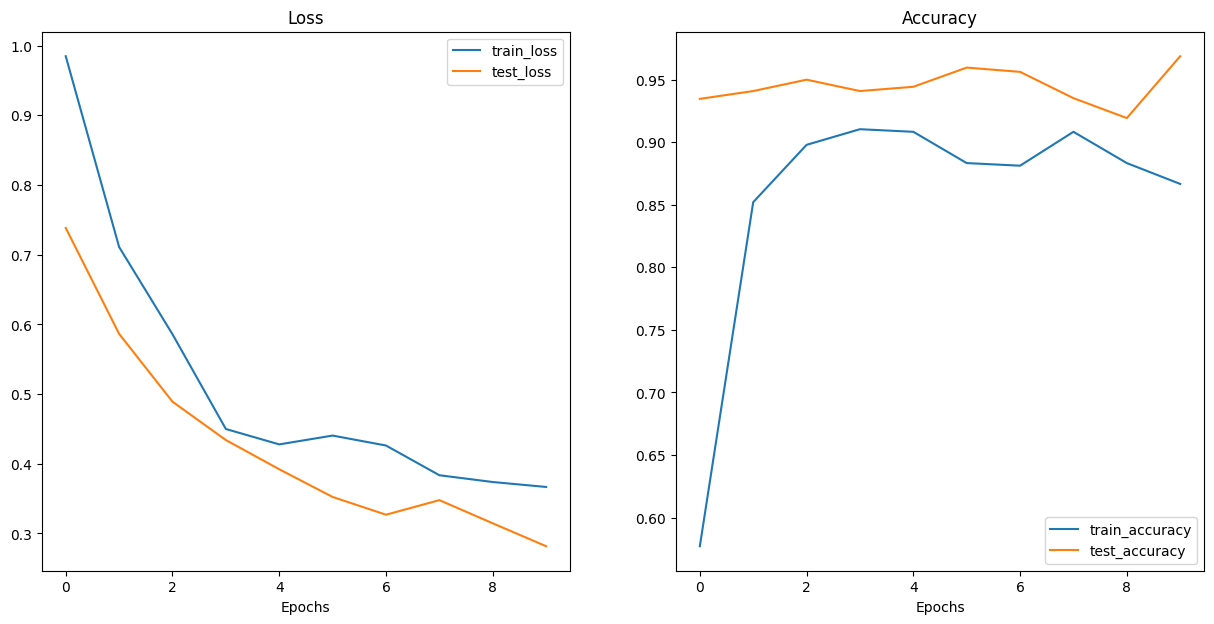

In [16]:
from helper_functions import plot_loss_curves
plot_loss_curves(effnetb2_results)

The loss curve for test data is lower than that for train data.

This is indicative that the model can be trained for longer and training data can be augmeneted to improve model performance.

### 3.5 Saving EffNetB2 feature extractor

In [17]:
from going_modular.going_modular import utils

# Save the model
utils.save_model(model=effnetb2,
                 target_dir="models",
                 model_name="09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth")

[INFO] Saving model to: models\09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth


### 3.6 Inspecting the size of our EffNetB2 feature extractor

Why would it be important to consider the size of a saved model?

If we're deploying our model to be used on a mobile app/website, there may be limited compute resources.

So if our model file is too large, we may not be able to store/run it on our target device.

In [18]:
from pathlib import Path

# Get the model size in bytes and convert it to MB
effnetb2_path = Path("models/09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth")
pretrained_effnetb2_model_size = round(effnetb2_path.stat().st_size/(1024*1024), 2)
print(f"Size of pretrained effnetb2 model: {pretrained_effnetb2_model_size} MB")

Size of pretrained effnetb2 model: 29.86 MB


### 3.7 Collecting EffNetB2 feature extractor stats

In [19]:
# Count number of parameters in EffNetB2
effnetb2_total_params = sum(torch.numel(params) for params in effnetb2.parameters())
effnetb2_total_params

7705221

In [20]:
# Create a dictionary with EFfNetB2 statistics
effnetb2_stats = {"test_loss": effnetb2_results["test_loss"][-1],
                  "test_acc": effnetb2_results["test_acc"][-1],
                  "number_of_parameters": effnetb2_total_params,
                  "model_size (MB)": pretrained_effnetb2_model_size}
effnetb2_stats

{'test_loss': 0.2817158490419388,
 'test_acc': 0.96875,
 'number_of_parameters': 7705221,
 'model_size (MB)': 29.86}

## 4. Creating a ViT (Vision Transformer) feature extractor
ViT_B_16 is the smallest Vision Transformer model and size of the model is a constraint for model deployment on edge devices.

As such, we will be using ViT_B_16 for comparison with effnetb2

### 4.1 Creating a function to make an ViT feature extractor model

In [21]:
import helper_functions
def create_vit_model(num_classes:int=3, # dfault output classes = 3 (pizza, steak, sushi)
                          seed:int=42):
  """Returns transforms and classes for an effnetb2 model with default weights
  Args:
  num_classes (int) - number of classes in the model
  seed (int) - random seed to initialize the trainable layers with"""

  helper_functions.set_seeds(42)

  # 1. Setup pretrained EffnetB3  with weights
  weights = torchvision.models.ViT_B_16_Weights.DEFAULT
  vit_model = torchvision.models.vit_b_16(weights=weights)

  # 2. Get EffNetB2 transforms
  vit_transforms = weights.transforms()

  # 3. Freeze all layers in base mdoel
  for param in vit_model.parameters():
    param.requires_grad=False

  # 4. Change classifier head with random seed for reproducibility
  torch.manual_seed(seed)
  vit_model.heads.head = nn.Linear(in_features=768,
                                   out_features=num_classes)
  vit_model.heads.head.requires_grad = True
  return vit_model, vit_transforms

In [22]:
# test_vit = torchvision.models.vit_b_16(weights=torchvision.models.ViT_B_16_Weights.DEFAULT)
vit, vit_transforms = create_vit_model()

In [23]:
summary(model=vit,
        input_size=[1, 3, 224, 224],
        col_width=20,
        col_names=["num_params","trainable", "input_size", "output_size"],
        row_settings=["var_names"])

Layer (type (var_name))                                      Param #              Trainable            Input Shape          Output Shape
VisionTransformer (VisionTransformer)                        768                  Partial              [1, 3, 224, 224]     [1, 3]
├─Conv2d (conv_proj)                                         (590,592)            False                [1, 3, 224, 224]     [1, 768, 14, 14]
├─Encoder (encoder)                                          151,296              False                [1, 197, 768]        [1, 197, 768]
│    └─Dropout (dropout)                                     --                   --                   [1, 197, 768]        [1, 197, 768]
│    └─Sequential (layers)                                   --                   False                [1, 197, 768]        [1, 197, 768]
│    │    └─EncoderBlock (encoder_layer_0)                   (7,087,872)          False                [1, 197, 768]        [1, 197, 768]
│    │    └─EncoderBlock (encoder_layer

### 4.2 Creating DataLoaders for ViT

In [24]:
from going_modular.going_modular import data_setup
train_dataloader_vit, test_dataloader_vit, class_names = data_setup.create_dataloaders(
    train_dir = train_dir,
    test_dir = test_dir,
    transform = vit_transforms,
    batch_size = 32
)

In [25]:
len(train_dataloader_vit), len(test_dataloader_vit), class_names

(15, 5, ['pizza', 'steak', 'sushi'])

### 4.3 Training ViT feature extractor

In [26]:
# Loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=vit.parameters(),
                             lr=1e-3)

In [27]:
# Training function
helper_functions.set_seeds()

from going_modular.going_modular.engine import train
vit.to(device)
vit_results = train(model=vit,
                    train_dataloader=train_dataloader_vit,
                    test_dataloader=test_dataloader_vit,
                    optimizer=optimizer,
                    loss_fn=loss_fn,
                    epochs=10,
                    device=device)

 10%|█         | 1/10 [00:24<03:39, 24.44s/it]

Epoch: 1 | train_loss: 0.7020 | train_acc: 0.7521 | test_loss: 0.2714 | test_acc: 0.9381


 20%|██        | 2/10 [00:47<03:08, 23.60s/it]

Epoch: 2 | train_loss: 0.2532 | train_acc: 0.9062 | test_loss: 0.1672 | test_acc: 0.9602


 30%|███       | 3/10 [01:09<02:41, 23.01s/it]

...

Epoch: 8 | train_loss: 0.0919 | train_acc: 0.9812 | test_loss: 0.0764 | test_acc: 0.9722


 90%|█████████ | 9/10 [03:17<00:21, 21.22s/it]

Epoch: 9 | train_loss: 0.0922 | train_acc: 0.9792 | test_loss: 0.0734 | test_acc: 0.9784


100%|██████████| 10/10 [03:38<00:00, 21.87s/it]

Epoch: 10 | train_loss: 0.0658 | train_acc: 0.9833 | test_loss: 0.0644 | test_acc: 0.9847


### 4.4 Inspecting ViT loss curves

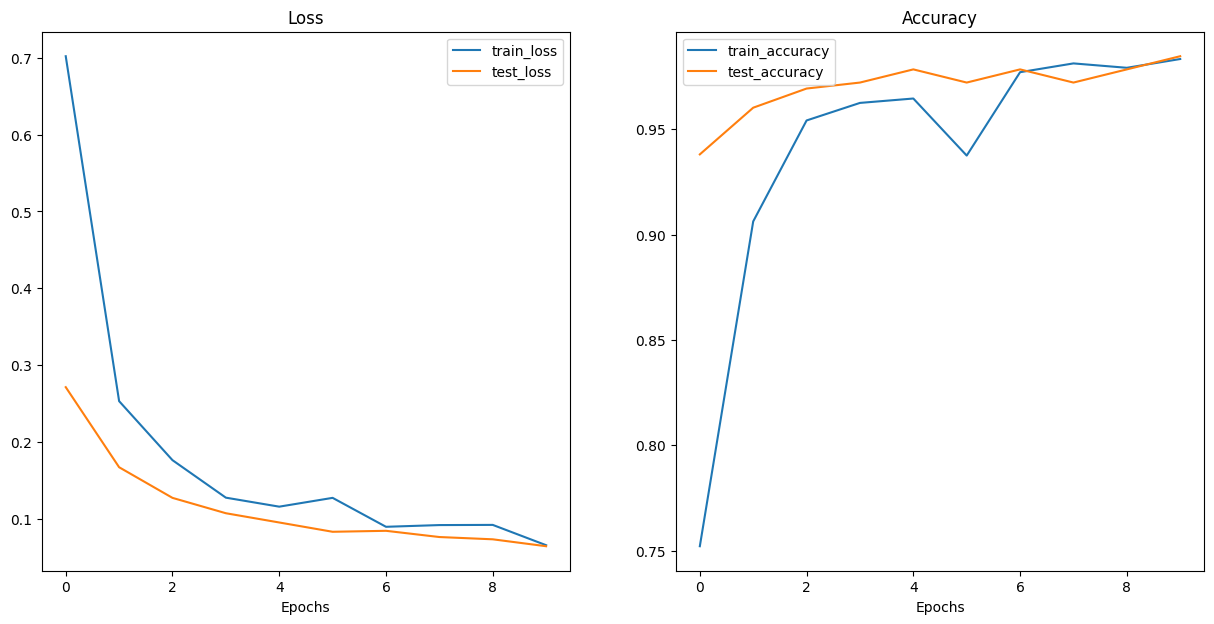

In [28]:
from helper_functions import plot_loss_curves
plot_loss_curves(vit_results)

### 4.5 Saving ViT feature extractor

In [29]:
from going_modular.going_modular import utils
utils.save_model(model=vit,
                 target_dir="models",
                 model_name="09_pretrained_vit_feature_extractor_pizza_steak_sushi_20_percent.pth")

[INFO] Saving model to: models\09_pretrained_vit_feature_extractor_pizza_steak_sushi_20_percent.pth


### 4.6 Inspecting the size of our ViT feature extractor model

In [30]:
from pathlib import Path

vit_model_path = Path("models/09_pretrained_vit_feature_extractor_pizza_steak_sushi_20_percent.pth")
pretrained_vit_model_size = round(vit_model_path.stat().st_size/(1024*1024),2)
print(f"Size of pretrained vit model: {pretrained_vit_model_size} MB")

Size of pretrained vit model: 327.37 MB


### 4.7 Collecting ViT feature extractor stats

In [31]:
# Count the number of parameters in ViT
vit_total_params = sum(torch.numel(params) for params in vit.parameters())
vit_total_params

85800963

In [32]:
# Create a dictionary with ViT statistics
vit_stats = {"test_loss": vit_results["test_loss"][-1],
             "test_acc": vit_results["test_acc"][-1],
             "number_of_parameters": vit_total_params,
             "model_size (MB)": pretrained_vit_model_size}
vit_stats

{'test_loss': 0.06443453896790743,
 'test_acc': 0.984659090909091,
 'number_of_parameters': 85800963,
 'model_size (MB)': 327.37}

## 5. Making predictions with our trained models and timing them
Both models satisfy our criteria of 95%+ accuracy.

How well do the two models -effnetb2 and vit- satisfy the latency requirement of 30ms?

To test the speed, we will:
1. Loop through test images
2. Time how long each model takes to make a prediction on the image


Function `pred_and_store()` will be created to do so.

First we will need a list of test image paths

In [33]:
from pathlib import Path

# Get all test data paths
test_data_paths = list(Path(test_dir).glob("*/*.jpg"))
len(test_data_paths), test_data_paths[:5]

(150,
 [WindowsPath('data/pizza_steak_sushi/test/pizza/1001116.jpg'),
  WindowsPath('data/pizza_steak_sushi/test/pizza/1032754.jpg'),
  WindowsPath('data/pizza_steak_sushi/test/pizza/1067986.jpg'),
  WindowsPath('data/pizza_steak_sushi/test/pizza/129666.jpg'),
  WindowsPath('data/pizza_steak_sushi/test/pizza/1315645.jpg')])

### 5.1 Creating a function to make predictions across the test dataset

Steps to create `pre_and_store()`:
1. Create a function that takes a list of paths, trained model and a series of transforms, a list of target class names, and a target device.
2. Create an empty list (can return a full list of all predictions later).
3. Loop through the target input paths (the rest of the steps will take place inside the loop).
4. Create and empty dicionary for each sample (prediction statistics will go in here).
5. Get the sample path and ground truth class from the filepath.
6. Start the prediction timer.
7. Open the image using `PIL.Image.open(path)`.
8. Transform the image to be usable with a given model.
9. Prepare the model for inference by sending it to the target device and turning on eval mode.
10. Turn on `torch.inference_mode()` and pass the target transformed image to the model and perform forward pass + claculate pred prob + pred class.
11. Add the pred probs + pred class to to empty dictionary from step 4.
12. End the prediction timer started in step 6 and add the time to the prediction dictionary.
13. See if the predicted class matches the ground truth class.
14. Append the prediction dictionary to the empty list of predictions we create in step 2.
15. Return the list of prediction dictionaries.


In [34]:
import pathlib
from typing import List, Dict
import PIL
from timeit import default_timer

import torch
import torchvision

from tqdm.auto import tqdm

def pred_and_store(paths:List[str],
                   model:torch.nn.Module,
                   transforms: torchvision.transforms,
                   class_names:List[str],
                   device:torch.device="cuda" if torch.cuda.is_available else "mps" if torch.backends.mps.is_available() else "cpu") -> List[Dict]:
  # Empty list to store the results to be returned
  res = []

  # Lopp through the target paths
  for path in tqdm(paths):
    # Create empty dictionary to store results for each inference
    res_dict = {}

    # Get path and ground truth class from the filepath.
    res_dict["image_path"] = path
    true_class = path.parent.stem # Gets "steak" from data/pizza_steak_sushi/test/steak/864661.jpg
    res_dict["class_name"] = true_class

    # Start the timer
    start_timer = default_timer()

    # Open image using `PIL.Image.open(path)`
    image = PIL.Image.open(path)

    # Transform the image
    image = transforms(image)

    # Send the image to target device
    image.to(device)

    # Prepare for inference by sending the model to target device and turning on eval mode
    model.to(device)
    model.eval()

    with torch.inference_mode():
      logits = model(image.unsqueeze(dim=0))
      pred_probs = torch.softmax(logits.squeeze(dim=0), dim=0)
      pred_class_index = torch.argmax(pred_probs, dim=0)

      # Add the prediction probability and predicted class to the dictionary
      res_dict["pred_prob"] = round(pred_probs.max().cpu().item(),4)
      res_dict["pred_class"] = class_names[pred_class_index.cpu()]

    # End the timer and add the time to the dictionary
    end_timer = default_timer()
    res_dict["time_taken"] = round(end_timer - start_timer, 4)
    res_dict["correct"] = true_class==res_dict["class_name"]

    # Append prediction dictionary to the list
    res.append(res_dict)
  return res

### 5.2 Making and timing predictions with EffNetB2

Let's test our `pred_and_store()` function.

Two things to note:
1. Device - we're going to hardcode our predictions to happen on CPU (because you won't always be sure of haivng a GPU when you deploy your model).
2. Transforms - we want to make sure each of the models are predicting on images that have been prepared with the appropriate transforms (e.g. EffNetB2 with `effnetb2_transforms`)

In [35]:
# Make predictions on test dataset with EffNetB2
effnetb2_pred_results = pred_and_store(paths=test_data_paths,
                                       model=effnetb2,
                                       transforms=effnetb2_transforms,
                                       class_names=class_names,
                                       device=torch.device("cpu")) #hardcoded for predictions to happen on CPU

100%|██████████| 150/150 [00:13<00:00, 11.18it/s]


In [36]:
# Turn the effnet_pred_results into a DataFram
import pandas as pd
effnetb2_pred_df = pd.DataFrame(effnetb2_pred_results)
effnetb2_pred_df.head()

,image_path,class_name,pred_prob,pred_class,time_taken,correct
0,data\pizza_steak_sushi\test\pizza\1001116.jpg,pizza,0.9941,pizza,0.1992,True
1,data\pizza_steak_sushi\test\pizza\1032754.jpg,pizza,0.4670,pizza,0.0765,True
2,data\pizza_steak_sushi\test\pizza\1067986.jpg,pizza,0.9918,pizza,0.0726,True
3,data\pizza_steak_sushi\test\pizza\129666.jpg,pizza,0.7093,pizza,0.0735,True
4,data\pizza_steak_sushi\test\pizza\1315645.jpg,pizza,0.7672,pizza,0.0710,True


In [37]:
# Number of correct predictions
effnetb2_pred_df.correct.value_counts()

correct
True    150
Name: count, dtype: int64

In [38]:
# Average time per prediction
effnetb2_average_time_per_pred = round(effnetb2_pred_df.time_taken.mean(), 4)
print(f"EffnetB2 average time per prediction: {effnetb2_average_time_per_pred}")

EffnetB2 average time per prediction: 0.089


**Note:** Prediction times will vary (much like training time) depending on the hardware being used.. generally the faster the compute (CPU or GPU), faster the predictions

In [39]:
# Add average time per prediction to EffNetB2 stats
effnetb2_stats["time_per_pred_cpu"] = effnetb2_average_time_per_pred
effnetb2_stats

{'test_loss': 0.2817158490419388,
 'test_acc': 0.96875,
 'number_of_parameters': 7705221,
 'model_size (MB)': 29.86,
 'time_per_pred_cpu': np.float64(0.089)}

### 5.3 Making and timing predictions with ViT

In [40]:
vit_pred_results = pred_and_store(paths=test_data_paths,
                                  model=vit,
                                  transforms=vit_transforms,
                                  class_names=class_names,
                                  device=torch.device("cpu"))#hardcoded for predictions to happen on CPU

100%|██████████| 150/150 [00:28<00:00,  5.22it/s]


In [41]:
# Turn the vit_pred_results into a DataFram
import pandas as pd
vit_pred_df = pd.DataFrame(vit_pred_results)
vit_pred_df.head()

,image_path,class_name,pred_prob,pred_class,time_taken,correct
0,data\pizza_steak_sushi\test\pizza\1001116.jpg,pizza,0.9987,pizza,0.3424,True
1,data\pizza_steak_sushi\test\pizza\1032754.jpg,pizza,0.9957,pizza,0.1853,True
2,data\pizza_steak_sushi\test\pizza\1067986.jpg,pizza,0.9987,pizza,0.1970,True
3,data\pizza_steak_sushi\test\pizza\129666.jpg,pizza,0.9869,pizza,0.1859,True
4,data\pizza_steak_sushi\test\pizza\1315645.jpg,pizza,0.9698,pizza,0.1913,True


In [42]:
vit_pred_df.correct.value_counts()

correct
True    150
Name: count, dtype: int64

In [43]:
# Average time per prediction
vit_average_time_per_pred = round(vit_pred_df.time_taken.mean(), 4)
print(f"ViT average time per prediction: {vit_average_time_per_pred}")

ViT average time per prediction: 0.1907


In [44]:
# Add average time per prediction to ViT stats
vit_stats["time_per_pred_cpu"] = vit_average_time_per_pred
vit_stats

{'test_loss': 0.06443453896790743,
 'test_acc': 0.984659090909091,
 'number_of_parameters': 85800963,
 'model_size (MB)': 327.37,
 'time_per_pred_cpu': np.float64(0.1907)}

## 6. Comparing model results, prediction times and size

In [45]:
# Turn stat dictionaries into DataFrame
df = pd.DataFrame([effnetb2_stats, vit_stats])

In [46]:
# Add column for model names
df["model"]=["EffNetB2", "ViT"]

# Convert accuracy to percentages
df["test_acc"] = round(df["test_acc"]*100,2)

In [47]:
df

,test_loss,test_acc,number_of_parameters,model_size (MB),time_per_pred_cpu,model
0,0.281716,96.88,7705221,29.86,0.0890,EffNetB2
1,0.064435,98.47,85800963,327.37,0.1907,ViT


Which model is better?
* `test_loss` (lower is better) - ViT
* `test_acc` (higher is better) - ViT
* `number_of_parameter` (generally lower is better*) - EffNetB2
  * *sometimes models with higher parameters can still perform fast. Generally though, if a model has more parameters, it takes longer to compute
* `model_size (MB)` - EffNetB2 (for our use case of deploying to a mobile device, generally lower is better)
* `timer_per_pred_cpu` - EffNetB2 (lower is better, highly dependent on the hardware)

Both models fail to achieve our goal of 30ms... however EffNetB2 is a lot closer to the target.

In [48]:
# Compare ViT to EffNetB2 across different characteristics
pd.DataFrame(df.set_index("model").loc["ViT"]/df.set_index("model").loc["EffNetB2"],
             columns = ["ViT to EffNetB2 ratios"]).T

,test_loss,test_acc,number_of_parameters,model_size (MB),time_per_pred_cpu
ViT to EffNetB2 ratios,0.228722,1.016412,11.135432,10.963496,2.142697


The trade off of increase in size, number of parameters, and time for inference is not worth it for the marginal gains in test_acc and test_loss for our problem.

### 6.1 Visualizing the performance vs. speed trade-off

We have compared our EffNetB2 and ViT feature extractor models. Now let's visualize the comparison with a speed vs. comparison plot.

We will do so with matplotlib

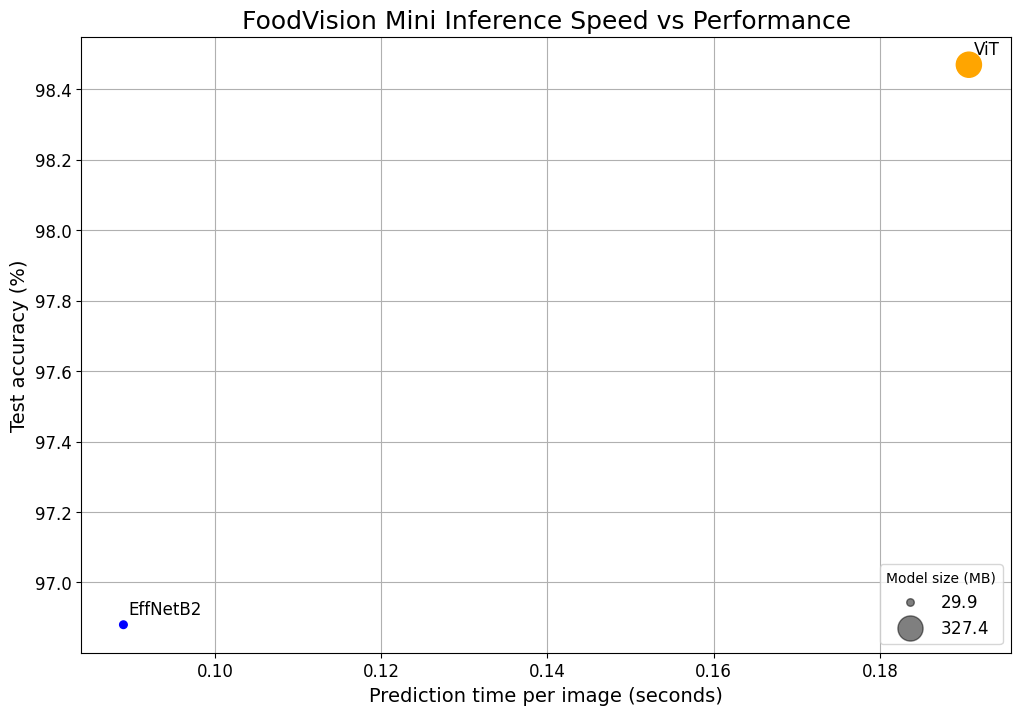

In [49]:
# 1. Create a plot from model comparison DataFrame
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(data=df,
                     x="time_per_pred_cpu",
                     y="test_acc",
                     c=["blue", "orange"],
                     s="model_size (MB)")

# 2. Add titles and labels
ax.set_title("FoodVision Mini Inference Speed vs Performance", fontsize=18)
ax.set_xlabel("Prediction time per image (seconds)", fontsize=14)
ax.set_ylabel("Test accuracy (%)", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.grid(True)

# 3. Annotate the samples on the scatter plot to make it clear what's going on
for index, row in df.iterrows():
  ax.annotate(text=row["model"],
              xy=(row["time_per_pred_cpu"]+0.0006, row["test_acc"]+0.03),
              size=12)

# 4. Create a legend based on the model sizes (model_size (MB))
handles, labels = scatter.legend_elements(prop="sizes", alpha=0.5)
model_size_legend = ax.legend(handles,
                              labels,
                              loc="lower right",
                              title="Model size (MB)",
                              fontsize=12)

# Save the figure
plt.savefig("09-foodvision-mini-inference-speed-vs-performance.png")
plt.show()

## 7. Bringing FoodVision Mini to life with a Gradio Demo

We have chosen to deploy EffNetB2 because it fulfils our criterias the best.

What is Gradio?
> Demo tool for ML models that makes the models available for anyone with a friendly web interface: https://www.gradio.app/


In [50]:
# Import Gradio
import gradio as gr

### 7.1 Gradio overview

Gradio helps create ML demos.

Why create a demo?

To make models available to other people for real world testing.

Deployment is as important as training.

The overall premise of Gradio is to map inputs -> functions/models -> outputs
https://www.gradio.app/docs#building-demos

### 7.2 Creating a function to map our inputs and outputs

In [51]:
# Put our model on the CPU
effnetb2 = effnetb2.to("cpu")

# Check the device
next(iter(effnetb2.parameters())).device

device(type='cpu')

Let's create a function called `predict()` to go from:

```
images of food -> ML model (EffNetB2) ->outputs (food class label, prediction time)
```

In [52]:
from typing import Tuple, Dict
from timeit import default_timer as timer

def predict(img) -> Tuple[Dict, float]:
  # Start a timer
  start = timer()

  # Transform the input image for use with EffNetB2
  img = effnetb2_transforms(img).unsqueeze(dim=0)

  # Put the model into eval mode, make prediction
  effnetb2.eval()
  with torch.inference_mode():
    logits = effnetb2(img).squeeze(dim=0) # remove batch dimension
    pred_probs = torch.softmax(logits, dim=0)

  # Create a prediction label and prediction probability dictionary
  pred_labels_and_probs = {class_names[i]:round(float(pred_probs[i]), 4) for i in range(len(class_names))}

  # Calculate pred time
  end = timer()
  pred_time = round(end-start, 4)

  # Return pred dict annd pred time
  return pred_labels_and_probs, pred_time

[INFO] Predicting on image at path: data\pizza_steak_sushi\test\sushi\1994748.jpg

{'pizza': 0.0628, 'steak': 0.3963, 'sushi': 0.5408}
0.0864


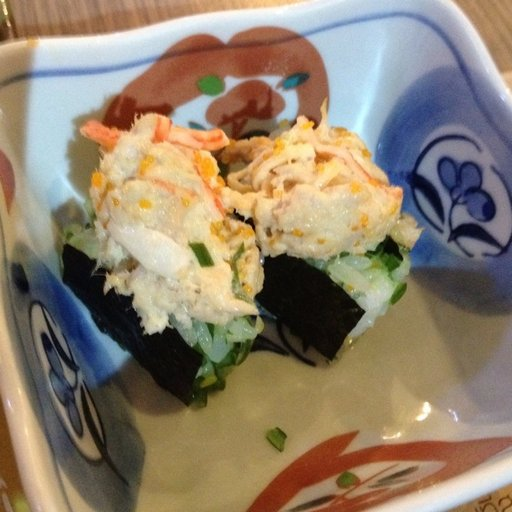

In [53]:
import random
from PIL import Image

# Get a list of all test image filepaths
test_data_paths = list(Path(test_dir).glob("*/*.jpg"))

# Randomly select a test image path
random_image_path = random.choice(test_data_paths)

# Open the target image
image = Image.open(random_image_path)
print(f"[INFO] Predicting on image at path: {random_image_path}\n")

# Predict on target image and print out the output
pred_dict, pred_time = predict(img=image)
print(pred_dict)
print(pred_time)
image

### 7.3 Creating a list of example images
The examples for Gradio can be created with `examples` parameter, see here: https://www.gradio.app/docs/gradio/examples

In [54]:
# Create list of example inputs to our Gradio demo
example_list = [str(filepath) for filepath in random.sample(test_data_paths, k=3)]
example_list

['data\\pizza_steak_sushi\\test\\pizza\\380739.jpg',
 'data\\pizza_steak_sushi\\test\\steak\\1972463.jpg',
 'data\\pizza_steak_sushi\\test\\pizza\\796922.jpg']

### 7.4 Building a Gradio Interface

Let's use `gr.Interface()` to go from:

```
input:image -> transform -> predict with EffNetB2 -> pred prob, time
```


In [55]:
import gradio as gr

# Create title, description and article
title = "FoodVision Mini 🍕🥩🍣"
description = "An EfficientNetB2 feature extractor computer vision model to classify images of food as pizza, steak or sushi."
article = "Created at [09. PyTorch Model Deployment](https://www.learnpytorch.io/09_pytorch_model_deployment/)."

# Create the Gradio demo
demo = gr.Interface(fn=predict, # map inputs to outputs
                    inputs=gr.Image(type="pil"),
                    outputs=[gr.Label(num_top_classes=3, label="Predictions"),
                             gr.Number(label="Prediction time (s)")],
                    examples=example_list,
                    title=title,
                    description=description,
                    article=article)

# Launch the demo
demo.launch(debug=True, # print errors locally
            share=True) # generate a publicl URL

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://8f8c27e8e9253f4d11.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://8f8c27e8e9253f4d11.gradio.live


## 8. Turning our FoodVision Mini Gradio Demo into a deployable app

Gradio Demos from Goofle Colab expire within 72 hours.

For a more permanent demo deployment solution, we are going to prepare app files so we can host them on Hugging Face Spaces: https://huggingface.co/spaces


### 8.1 What is Hugging Face Spaces?

Hugging Face Spaces offers a simple way to host ML demo apps - to create ML protfolio, showcase projects and collaborate with others.

### 8.2 Deployed Gradio App Structure
To upload the demo app, we'll need everything in one directory.

```
Colab -> folder with all Gradio app files -> upload app files to Hugging Face Space -> deploy
```

By the end our file structure will look like this:
```
demos/
└── foodvision_mini/
    ├── 09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth
    ├── app.py
    ├── examples/
    │   ├── example_1.jpg
    │   ├── example_2.jpg
    │   └── example_3.jpg
    ├── model.py
    └── requirements.txt
```

Why use this structure?
It's one of the simplest to start with.

### 8.3 Creating a `demos` folder to store our FoodVision app files

In [56]:
import shutil
from pathlib import Path

# Create FoodVision mini demo path
foodvision_mini_demo_path = Path("demos/foodvision_mini/")

# Remove files that might exist and create a new directory
if foodvision_mini_demo_path.exists():
  shutil.rmtree(foodvision_mini_demo_path)
foodvision_mini_demo_path.mkdir(exist_ok=True,
                                parents=True)

!ls demos/foodvision_mini

'ls' is not recognized as an internal or external command,
operable program or batch file.


### 8.4 Creating a folder of example images to use with our FoodVision Mini demo

What we want:
* 3 images in an examples/directory
* Images should be from the test set

In [57]:
import shutil
from pathlib import Path

# Create an examples directory
foodvision_mini_examples_path = foodvision_mini_demo_path/"examples"
foodvision_mini_examples_path.mkdir(parents=True,
                                    exist_ok=True)

In [58]:
# Collect three random test dataset image paths
foodvision_mini_examples = [Path("data/pizza_steak_sushi/test/pizza/1067986.jpg"),
                             Path("data/pizza_steak_sushi/test/steak/2315011.jpg"),
                             Path("data/pizza_steak_sushi/test/sushi/720302.jpg")]

# Copy the three images to the examples directory
for example in foodvision_mini_examples:
  destination = foodvision_mini_examples_path/example.name
  print(f"[INFO] Copying {example} to {destination}")
  shutil.copy2(src=example,
               dst=destination)

[INFO] Copying data\pizza_steak_sushi\test\pizza\1067986.jpg to demos\foodvision_mini\examples\1067986.jpg
[INFO] Copying data\pizza_steak_sushi\test\steak\2315011.jpg to demos\foodvision_mini\examples\2315011.jpg
[INFO] Copying data\pizza_steak_sushi\test\sushi\720302.jpg to demos\foodvision_mini\examples\720302.jpg


Let's now verify that we can get a list of lists from our `examples/` directory.

In [59]:
import os

# Get example filepaths in a list of lists
example_list = [["examples/"+example] for example in os.listdir(foodvision_mini_examples_path)]
example_list

[['examples/1067986.jpg'], ['examples/2315011.jpg'], ['examples/720302.jpg']]

### 8.5 Moving our trained EffNetB2 model to our FoodVision Mini demo directory

In [60]:
import shutil

# Create a source path for our target model
effnetb2_foodvision_mini_model_path = "models/09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth"

# Create a destination path for our target model
effnetb2_foodvision_mini_model_destination = foodvision_mini_demo_path / effnetb2_foodvision_mini_model_path.split("/")[1]

# Try to move the model file
try:
  print(f"[INFO] Attempting to move {effnetb2_foodvision_mini_model_path} to {effnetb2_foodvision_mini_model_destination}")

  # Move the model
  shutil.move(src=effnetb2_foodvision_mini_model_path,
              dst=effnetb2_foodvision_mini_model_destination)

  print(f"[INFO] Model move complete.")
  # If the model has already been moved, check if it exists
except:
  print(f"[INFO] No model found at {effnetb2_foodvision_mini_model_path}, perhaps its already been moved?")
  print(f"[INFO] Model exists at {effnetb2_foodvision_mini_model_destination}: {effnetb2_foodvision_mini_model_destination.exists()}")

[INFO] Attempting to move models/09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth to demos\foodvision_mini\09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth
[INFO] Model move complete.


### 8.6 Create `model.py` script to instantiate an EffNetB2 model

We have saved a `.pth` model `state_dict` and want to load it into a model instance.

Let's move our `create_effnetb2_model()` function to a script so we can reuse it.

In [61]:
%%writefile demos/foodvision_mini/model.py
import torch
from torch import nn
import torchvision

def create_effnetb2_model(num_classes:int=3, # dfault output classes = 3 (pizza, steak, sushi)
                          seed:int=42):
  """Returns transforms and classes for an effnetb2 model with default weights
  Args:
  num_classes (int) - number of classes in the model
  seed (int) - random seed to initialize the trainable layers with"""

  # 1. Setup pretrained EffnetB3  with weights
  weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
  effnetb2_model = torchvision.models.efficientnet_b2(weights=weights)

  # 2. Get EffNetB2 transforms
  effnetb2_transforms = weights.transforms()

  # 3. Freeze all layers in base mdoel
  for param in effnetb2_model.features.parameters():
    param.requires_grad=False

  # 4. Change classifier head with random seed for reproducibility
  torch.manual_seed(seed)
  effnetb2_model.classifier = nn.Sequential(
      nn.Dropout(p=0.3, inplace=True),
      nn.Linear(in_features=1408,
                out_features=num_classes)
  )
  return effnetb2_model, effnetb2_transforms

Writing demos/foodvision_mini/model.py


### 8.7 Turning our FoodVision Mini Gradio app into a Python script (`app.py`)

In [62]:
%%writefile demos/foodvision_mini/app.py
### 1. Imports and class names setup ###
import gradio as gr
import os
import torch

from model import create_effnetb2_model
from timeit import default_timer as timer
from typing import Tuple, Dict

# Setup class names
class_names = ["pizza", "steak", "sushi"]

### 2. Model and transforms preparation ###
effnetb2, effnetb2_transforms = create_effnetb2_model(
    num_classes=len(class_names)
)

# Load saved weights
effnetb2.load_state_dict(
    torch.load(
        f="09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth",
        map_location=torch.device("cpu") # Load the model to the cpu
    )
)

### 3. Predict function ###
def predict(img) -> Tuple[Dict, float]:
  # Start a timer
  start = timer()

  # Transform the input image for use with EffNetB2
  img = effnetb2_transforms(img).unsqueeze(dim=0)

  # Put the model into eval mode, make prediction
  effnetb2.eval()
  with torch.inference_mode():
    logits = effnetb2(img).squeeze(dim=0) # remove batch dimension
    pred_probs = torch.softmax(logits, dim=0)

  # Create a prediction label and prediction probability dictionary
  pred_labels_and_probs = {class_names[i]:round(float(pred_probs[i]), 4) for i in range(len(class_names))}

  # Calculate pred time
  end = timer()
  pred_time = round(end-start, 4)

  # Return pred dict annd pred time
  return pred_labels_and_probs, pred_time

### 4. Gradio app ###
import gradio as gr

# Create title, description and article
title = "FoodVision Mini 🍕🥩🍣"
description = "An EfficientNetB2 feature extractor computer vision model to classify images of food as pizza, steak or sushi."
article = "Created at [09. PyTorch Model Deployment](https://www.learnpytorch.io/09_pytorch_model_deployment/)."

# Create example list
example_list = [["examples/"+example] for example in os.listdir("examples")]

# Create the Gradio demo
demo = gr.Interface(fn=predict, # map inputs to outputs
                    inputs=gr.Image(type="pil"),
                    outputs=[gr.Label(num_top_classes=3, label="Predictions"),
                             gr.Number(label="Prediction time (s)")],
                    examples=example_list,
                    title=title,
                    description=description,
                    article=article)

# Launch the demo
demo.launch(debug=True, # print errors locally
            share=True) # generate a public URL

Writing demos/foodvision_mini/app.py


### 8.8 Creating a requirements file for FoodVision mini (`requirements.txt`)
The requirements file will tell our Hugging Face Space what software dependencies our app requires.

The three main ones are:
* `torch`
* `torchvision`
* `gradio`

In [63]:
%%writefile demos/foodvision_mini/requirements.txt
torch==2.10.0
torchvision==0.25.0
gradio>=5.50

Writing demos/foodvision_mini/requirements.txt


## 9. Deploying FoodVision Mini app to Hugging Face Spaces

There are two main options for uploading to a Hugging Face Space (also called a Hugging Face Repository, similar to a git repository):

* Uploading via the Hugging Face Web interface (easiest).
* Uploading via the command line or terminal.
> *Bonus: huggingface_hub library can also be used to interact with Hugging Face. This would be a good extension to the above two options.

### 9.1 Downloading our FoodVision Mini app files

We want to download our `foodvision_mini` demo app so we can upload it ot Hugging Face Spaces

In [64]:
!ls demos/foodvision_mini/

'ls' is not recognized as an internal or external command,
operable program or batch file.


In [65]:
!ls demos/foodvision_mini/examples

'ls' is not recognized as an internal or external command,
operable program or batch file.


In [66]:
# Change into the foodvision_mini directory and zip it from the inside
!cd demos/foodvision_mini/ && zip -r ../foodvision_mini.zip * -x "*.pyc" "*.ipynb" "*__pycache__" "*ipynb_checkpoints*"

'zip' is not recognized as an internal or external command,
operable program or batch file.


In [67]:
# Download
try:
  from google.colab import files
  files.download("demos/foodvision_mini.zip")
except:
  print(f"Not running in Google Colab, can't use google.colab.files.download(), please download foodvision_mini.zip manually.")

Not running in Google Colab, can't use google.colab.files.download(), please download foodvision_mini.zip manually.


### 9.2 Running our Gradio demo app locally

### 9.3 Uploading our FoodVision Mini Gradio demo to Hugging Face Spaces

1. Create a Space on Hugging Face Spaces
2. Create a local repository and clone the Hugging Face Spaces repository.
3. Copy the app files to the cloned repo
4. Add the model weights to git lfs
5. Update the gitattributes file
6. Stage and commit the files.
> *This might require creating a token from Hugging Face Spaces
7. Push the commit
8. Wait for the app to finish building and share

https://huggingface.co/spaces/AvalonEnjoyer/foodvision_mini_AE

We can also share our app by embedding it: https://huggingface.co/docs/hub/spaces-embed

In [68]:
# IPython is a library to help make Python interactive
from IPython.display import IFrame

# Embed FoodVision Mini Gradio demo
IFrame(src="https://huggingface.co/spaces/AvalonEnjoyer/foodvision_mini_AE", width=900, height=750)

## 10. Creating FoodVision Big

FoodVision Mini works well with 3 classes (pizza, steak, sushi).

So all of our experimenting has paid off.

Now the next step is to make FoodVision Big with all 101 classes of the Food101 dataset.

### 10.1 Creating a model for FoodVision Big + transforms

In [69]:
#Create Food101 model and transforms
effnetb2_food101, effnetb2_transforms = create_effnetb2_model(num_classes=101)

from torchinfo import summary
summary(model=effnetb2_food101,
        input_size=(1,3,224,224),
        col_names=["num_params", "input_size", "output_size", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Param #              Input Shape          Output Shape         Trainable
EfficientNet (EfficientNet)                                  --                   [1, 3, 224, 224]     [1, 101]             Partial
├─Sequential (features)                                      --                   [1, 3, 224, 224]     [1, 1408, 7, 7]      False
│    └─Conv2dNormActivation (0)                              --                   [1, 3, 224, 224]     [1, 32, 112, 112]    False
│    │    └─Conv2d (0)                                       (864)                [1, 3, 224, 224]     [1, 32, 112, 112]    False
│    │    └─BatchNorm2d (1)                                  (64)                 [1, 32, 112, 112]    [1, 32, 112, 112]    False
│    │    └─SiLU (2)                                         --                   [1, 32, 112, 112]    [1, 32, 112, 112]    --
│    └─Sequential (1)                                        --                   [1, 3

Since we're working with a larger dataset, we may want to introduce some regularization techniques.

With larger datasets and larger models, overfitting becomes more of a problem.

Let's use TrivialAugment as our data augmentation technique which helps with regularization in computer vision models.

https://pytorch.org/blog/how-to-train-state-of-the-art-models-using-torchvision-latest-primitives/

In [70]:
food101_train_transforms = torchvision.transforms.Compose([
    torchvision.transforms.TrivialAugmentWide(),
    effnetb2_transforms
])

In [71]:
food101_train_transforms

Compose(
    TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
    ImageClassification(
    crop_size=[288]
    resize_size=[288]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)
)

### 10.2 Getting data for FoodVision Big

In [73]:
# Get Food101 dataset
from torchvision import datasets
# Setup data directory
from pathlib import Path
data_dir = Path("data")

# Get the training data (~750 images x 101 classes)
train_data = datasets.Food101(root=data_dir,
                              split="train",
                              transform=food101_train_transforms, # augment the training data
                              download=True)

# Get the testing data (~250 images x 101 classes)
test_data = datasets.Food101(root=data_dir,
                             split="test",
                             transform=effnetb2_transforms, # no augmentation on teh test data
                             download=True)

In [74]:
# Get Food101 class names
food101_class_names = train_data.classes

# View the first 10
food101_class_names[:10]

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito']

### 10.3 Creating a subset of the Food101 dataset for faster experimenting

Why create a subset?

We want to our experimenting to be quick so that we can figure out what works and what does not.

We know FoodVision Mini works really well but this is the first time we've upgraded to 101 clasess.

To do so, let's make a subset of 30% of the data from the Food101 dataset (training and test).


Out short-term goal: to beat the original Food101 paper result of 56.4% accuracy on the test dataset. (See the paper: https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/static/bossard_eccv14_food-101.pdf)

We want to beat this using newer DL techniques and with only 30% of the dataset.

In [ ]:
from torch.utils.data import random_split

def split_dataset(dataset:torchvision.datasets,
                  split_size:float=0.2,
                  seed:int=42):
  """
  Creates two random splits of given dataset
  Args:
  dataset (torchvision.datasets): dataset to create splits from
  split_size (float): proportion of dataset to be split with lengths: split_size and 1-split_size
  seed (int): random seed for random splits
  Returns:
  random_split_1, random_split_2 with lengths: split_size*len(dataset) and (1-split_size)*len(datasets)
  """
  # Create split lengths based on original dataset length
  print(f"[INFO] Splitting dataset of length {len(dataset)} into splits of size: {split_size*len(dataset)} and {(1-split_size)*len(dataset)}")
  random_split_1, random_split_2 = random_split(dataset=dataset,
                                                lengths=[split_size, 1-split_size],
                                                generator=torch.manual_seed(seed))

  return random_split_1, random_split_2

In [ ]:
# Create training 30% split Food101
train_data_Food101_30_percent, _ = split_dataset(dataset=train_data,
                                              split_size=0.3)

# Create testing 30% split Food101
test_data_Food101_30_percent, _ = split_dataset(dataset=test_data,
                                                split_size=0.3)

[INFO] Splitting dataset of length 75750 into splits of size: 22725.0 and 53025.0
[INFO] Splitting dataset of length 25250 into splits of size: 7575.0 and 17675.0


### 10.4 Turning our Food101 datasets into `DataLoader`s

In [ ]:
from torch.utils.data import DataLoader
BATCH_SIZE=32
NUM_WORKERS=1 # Setting a positive value allows pytorch to use more cpu where possible

In [ ]:
train_dataloader_food101_30_percent = DataLoader(dataset=train_data_Food101_30_percent,
                                      batch_size=BATCH_SIZE,
                                      shuffle=True,
                                      num_workers=NUM_WORKERS)
test_dataloader_food101_30_percent = DataLoader(dataset=test_data_Food101_30_percent,
                                     batch_size=BATCH_SIZE,
                                     shuffle=False,
                                     num_workers=NUM_WORKERS)

In [ ]:
len(train_dataloader_food101_30_percent), len(test_dataloader_food101_30_percent)

(2368, 790)

### 10.5 Training FoodVision Big
Hyperparameters:
* 10 epochs
* Optimizer: torch.optim.Adam(lr=1e-3)
* Loss function: torch.nn.CrossEntropyLoss(label_smoothing=0.1)


Why use label smoothing?
Label smoothing is a regularization technique. The illustration below shows to examples of a classifer's softmax output:

Without label smoothing and 5 clasees:
```
[0.00, 0.00, 0.99, 0.01, 0.00]
```

With label smoothing and 5 classes:
```
[0.01, 0.01, 0.96, 0.01, 0.01]
```

In [ ]:
# Loss function
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

# Optimizer
optimizer = torch.optim.Adam(params=effnetb2_food101.parameters(),
                             lr=1e-3)

In [ ]:
from going_modular.going_modular import engine

helper_functions.set_seeds()
effnetb2_food101_results = engine.train(model=effnetb2_food101,
                                        train_dataloader=train_dataloader_food101_30_percent,
                                        test_dataloader=test_dataloader_food101_30_percent,
                                        optimizer=optimizer,
                                        loss_fn=loss_fn,
                                        epochs=10,
                                        device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 3.4336 | train_acc: 0.3188 | test_loss: 2.5942 | test_acc: 0.5198
Epoch: 2 | train_loss: 2.7623 | train_acc: 0.4549 | test_loss: 2.3524 | test_acc: 0.5677
Epoch: 3 | train_loss: 2.6166 | train_acc: 0.4910 | test_loss: 2.2845 | test_acc: 0.5782
Epoch: 4 | train_loss: 2.5601 | train_acc: 0.5037 | test_loss: 2.2359 | test_acc: 0.5898
Epoch: 5 | train_loss: 2.5127 | train_acc: 0.5124 | test_loss: 2.2196 | test_acc: 0.5918
Epoch: 6 | train_loss: 2.4870 | train_acc: 0.5230 | test_loss: 2.2087 | test_acc: 0.6075
Epoch: 7 | train_loss: 2.4571 | train_acc: 0.5329 | test_loss: 2.2197 | test_acc: 0.5897
Epoch: 8 | train_loss: 2.4482 | train_acc: 0.5328 | test_loss: 2.1832 | test_acc: 0.6031
Epoch: 9 | train_loss: 2.4419 | train_acc: 0.5358 | test_loss: 2.1910 | test_acc: 0.6033
Epoch: 10 | train_loss: 2.4137 | train_acc: 0.5407 | test_loss: 2.1801 | test_acc: 0.6029


### 10.6 Inspecting the loss curves of FoodVision Big model

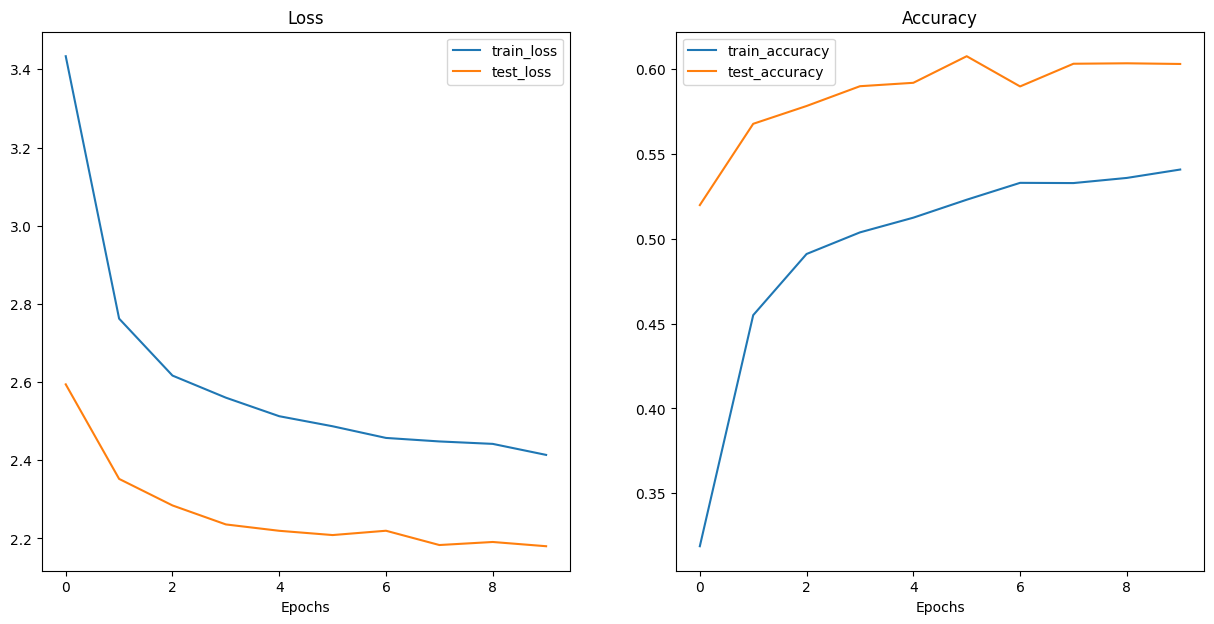

In [ ]:
from helper_functions import plot_loss_curves
plot_loss_curves(effnetb2_food101_results)

### 10.7 Save and load FoodVision Big model

In [ ]:
from going_modular.going_modular import utils

# Create a model path
effnetb2_food101_model_path = "09_pretrained_effnetb2_feature_extractor_food101.pth"

# Save FoodVision Big model
utils.save_model(model=effnetb2_food101,
                 target_dir="models/",
                 model_name=effnetb2_food101_model_path)

[INFO] Saving model to: models/09_pretrained_effnetb2_feature_extractor_food101.pth


In [ ]:
# Create Food101 compatible EffNetB2 instance
loaded_effnetb2_food101, effnetb2_transforms = create_effnetb2_model(num_classes=101)

# Load the saved modeel's state_dict()
loaded_effnetb2_food101.load_state_dict(
    torch.load("models/09_pretrained_effnetb2_feature_extractor_food101.pth")
)

<All keys matched successfully>

### 10.8 Checking FoodVision Big model size

In [ ]:
from pathlib import Path

effnetb2_food101_model_path = Path("models/09_pretrained_effnetb2_feature_extractor_food101.pth")
pretrained_effnetb2_food101_model_size = round(effnetb2_food101_model_path.stat().st_size/(1024*1024),2)
print(f"Size of pretrained vit model: {pretrained_effnetb2_food101_model_size} MB")

Size of pretrained vit model: 30.38 MB


## 11. Turning our FoodVision Big model into a deployable app

Why deploy a model?

Deploying a model allows you to see how your model goes in the real-world (the ultimate test set).

Outline for the FoodVision Big app:
```
demos/
  foodvision_big/
    09_pretrained_effnetb2_feature_extractor_food101_20_percent.pth
    app.py
    class_names.txt
    examples/
      example_1.jpg
    model.py
    requirements.txt
```

In [ ]:
from pathlib import Path

# Create FoodVision Big demo path
foodvision_big_demo_path = Path("demos/foodvision_big/")

# Create FoodVision Big demo directory
foodvision_big_demo_path.mkdir(parents=True,
                               exist_ok=True)

# Make FoodVision Big demo examples directory
(foodvision_big_demo_path/"examples").mkdir(parents=True, exist_ok=True)

### 11.1 Moving test images from test directory to `examples` directory

In [ ]:
foodvision_big_examples_path = foodvision_big_demo_path/"examples"
foodvision_big_examples_path

PosixPath('demos/foodvision_big/examples')

In [ ]:
# Collect three random test dataset image paths
foodvision_big_examples = [Path("data/food-101/images/apple_pie/1005649.jpg"),
                           Path("data/food-101/images/hummus/1015464.jpg"),
                           Path("data/food-101/images/prime_rib/59497.jpg")]

# Copy the three images to the examples directory
for example in foodvision_big_examples:
  destination = foodvision_big_examples_path/example.name
  print(f"[INFO] Copying {example} to {destination}")
  shutil.copy2(src=example,
               dst=destination)

[INFO] Copying data/food-101/images/apple_pie/1005649.jpg to demos/foodvision_big/examples/1005649.jpg
[INFO] Copying data/food-101/images/hummus/1015464.jpg to demos/foodvision_big/examples/1015464.jpg
[INFO] Copying data/food-101/images/prime_rib/59497.jpg to demos/foodvision_big/examples/59497.jpg


### 11.2 Moving model to the demo folder

In [ ]:
import shutil

# Create a destination path for our target model
effnetb2_foodvision_big_model_destination = foodvision_big_demo_path / effnetb2_food101_model_path.stem

# Try to move the model file
try:
  print(f"[INFO] Attempting to move {effnetb2_food101_model_path} to {effnetb2_foodvision_big_model_destination}")

  # Move the model
  shutil.move(src=effnetb2_food101_model_path,
              dst=effnetb2_foodvision_big_model_destination)

  print(f"[INFO] Model move complete.")
  # If the model has already been moved, check if it exists
except:
  print(f"[INFO] No model found at {effnetb2_food101_model_path}, perhaps its already been moved?")
  print(f"[INFO] Model exists at {effnetb2_foodvision_big_model_destination}: {effnetb2_foodvision_big_model_destination.exists()}")

[INFO] Attempting to move models/09_pretrained_effnetb2_feature_extractor_food101.pth to demos/foodvision_big/09_pretrained_effnetb2_feature_extractor_food101
[INFO] Model move complete.


### 11.3 Saving Food101 class names to file (`class_names.txt`)

In [ ]:
# Create path to Food101 class names
foodvision_big_class_names_path = foodvision_big_demo_path/"class_names.txt"
foodvision_big_class_names_path

PosixPath('demos/foodvision_big/class_names.txt')

In [ ]:
# Write Food101 class names to text file
with open(foodvision_big_class_names_path, "w") as f:
  print(f"[INFO] Saving Food101 class names to {foodvision_big_class_names_path}")
  f.write("\n".join(food101_class_names)) # new line per class name

[INFO] Saving Food101 class names to demos/foodvision_big/class_names.txt


In [ ]:
# Open Food101 class names file and read each line into a list
with open(foodvision_big_class_names_path, "r") as f:
  food101_class_names_loaded = [food.strip() for food in f.readlines()]
food101_class_names_loaded[:10]

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito']

### 11.4 Turning our FoodVision Big model into a Python script(`model.py`)

In [ ]:
%%writefile demos/foodvision_big/model.py
import torch
from torch import nn
import torchvision

def create_effnetb2_model(num_classes:int=101,
                          seed:int=42):
  """Returns transforms and classes for an effnetb2 model with default weights
  Args:
  num_classes (int) - number of classes in the model
  seed (int) - random seed to initialize the trainable layers with"""

  # 1. Setup pretrained EffnetB3  with weights
  weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
  effnetb2_model = torchvision.models.efficientnet_b2(weights=weights)

  # 2. Get EffNetB2 transforms
  effnetb2_transforms = weights.transforms()

  # 3. Freeze all layers in base mdoel
  for param in effnetb2_model.features.parameters():
    param.requires_grad=False

  # 4. Change classifier head with random seed for reproducibility
  torch.manual_seed(seed)
  effnetb2_model.classifier = nn.Sequential(
      nn.Dropout(p=0.3, inplace=True),
      nn.Linear(in_features=1408,
                out_features=num_classes)
  )
  return effnetb2_model, effnetb2_transforms

Writing demos/foodvision_big/model.py


### 11.5 Turning our FoodVision Big Gradio app into a Python script (`app.py`)

In [ ]:
%%writefile demos/foodvision_big/app.py
### 1. Imports and class names setup ###
import gradio as gr
import os
import torch

from model import create_effnetb2_model
from timeit import default_timer as timer
from typing import Tuple, Dict

# Class names setup
with open("class_names.txt", r) as f:
  class_names = [food_name.strip() for food_name in f.readlines()]

### 2. Model and transforms preparation ###
# Create model and transforms
effnetb2, effnetb2_transforms = create_effnetb2_model(num_classes=101)

# Load the saved weights
effnetb2.load_state_dict(
    torch.load(f="models/09_pretrained_effnetb2_feature_extractor_food101.pth",
               map_location=torch.device("cpu"))
    )

### 3. Predict function ###
def predict(img) -> Tuple[Dict, float]:
  # Start a timer
  start = timer()

  # Transform the input image for use with EffNetB2
  img = effnetb2_transforms(img).unsqueeze(dim=0)

  # Put the model into eval mode, make prediction
  effnetb2.eval()
  with torch.inference_mode():
    logits = effnetb2(img).squeeze(dim=0) # remove batch dimension
    pred_probs = torch.softmax(logits, dim=0)

  # Create a prediction label and prediction probability dictionary
  pred_labels_and_probs = {class_names[i]:round(float(pred_probs[i]), 4) for i in range(len(class_names))}

  # Calculate pred time
  end = timer()
  pred_time = round(end-start, 4)

  # Return pred dict annd pred time
  return pred_labels_and_probs, pred_time


### 4. Gradio app ###
import gradio as gr

# Create title, description and article
title = "FoodVision Big"
description = "An EfficientNetB2 feature extractor computer vision model to classify 101 classes of Food from Food101 dataset"
article = "Created at [09. PyTorch Model Deployment](https://www.learnpytorch.io/09_pytorch_model_deployment/)."

# Create example list
example_list = [["examples/"+example] for example in os.listdir("examples")]

# Create the Gradio demo
demo = gr.Interface(fn=predict, # map inputs to outputs
                    inputs=gr.Image(type="pil"),
                    outputs=[gr.Label(num_top_classes=5, label="Predictions"),
                             gr.Number(label="Prediction time (s)")],
                    examples=example_list,
                    title=title,
                    description=description,
                    article=article)

# Launch the demo
demo.launch(debug=True, # print errors locally
            share=True) # generate a public URL


Writing demos/foodvision_big/app.py


### 11.6 Creating a  requirements file for FoodVision Big (`requirements.txt`)

In [ ]:
%%writefile demos/foodvision_big/requirements.txt
torch==2.10.0
torchvision==0.25.0
gradio>=5.50

Writing demos/foodvision_big/requirements.txt


### 11.7 Downloading FoodVision Big app files

In [ ]:
# Change into the foovision_big directory and zip it
!cd demos/foodvision_big && zip -r ../foodvision_big.zip * -x "*.pyc" "*.ipynb" "*__pycache__" "*ipynb_checkpoints*"

  adding: 09_pretrained_effnetb2_feature_extractor_food101 (deflated 8%)
  adding: app.py (deflated 55%)
  adding: class_names.txt (deflated 48%)
  adding: examples/ (stored 0%)
  adding: examples/1015464.jpg (deflated 1%)
  adding: examples/59497.jpg (deflated 0%)
  adding: examples/1005649.jpg (deflated 0%)
  adding: model.py (deflated 52%)
  adding: requirements.txt (deflated 4%)


In [ ]:
# Download
try:
  from google.colab import files
  files.download("demos/foodvision_big.zip")
except:
  print(f"Not running in Google Colab, can't use google.colab.files.download(), please download foodvision_big.zip manually.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 12. Food Vision Big with all of the data

In [75]:
#Create Food101 model and transforms
effnetb2_food101, effnetb2_transforms = create_effnetb2_model(num_classes=101)

In [87]:
from torch.utils.data import DataLoader
BATCH_SIZE=256
NUM_WORKERS=1 # Setting a positive value allows pytorch to use more cpu where possible

In [88]:
train_dataloader_food101 = DataLoader(dataset=train_data,
                                      batch_size=BATCH_SIZE,
                                      shuffle=True,
                                      num_workers=NUM_WORKERS)
test_dataloader_food101 = DataLoader(dataset=test_data,
                                     batch_size=BATCH_SIZE,
                                     shuffle=False,
                                     num_workers=NUM_WORKERS)

In [89]:
len(train_dataloader_food101), len(test_dataloader_food101)

(296, 99)

In [90]:
# Loss function
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

# Optimizer
optimizer = torch.optim.Adam(params=effnetb2_food101.parameters(),
                             lr=1e-3)

In [91]:
device

device(type='cuda')

In [95]:
from going_modular.going_modular import engine

helper_functions.set_seeds()
effnetb2_food101_results = engine.train(model=effnetb2_food101,
                                        train_dataloader=train_dataloader_food101,
                                        test_dataloader=test_dataloader_food101,
                                        optimizer=optimizer,
                                        loss_fn=loss_fn,
                                        epochs=10,
                                        device=device)

 10%|█         | 1/10 [18:25<2:45:49, 1105.53s/it]

Epoch: 1 | train_loss: 2.3526 | train_acc: 0.5656 | test_loss: 1.9793 | test_acc: 0.6677


 20%|██        | 2/10 [36:45<2:26:58, 1102.28s/it]

Epoch: 2 | train_loss: 2.3648 | train_acc: 0.5595 | test_loss: 1.9788 | test_acc: 0.6685


 30%|███       | 3/10 [54:01<2:05:05, 1072.22s/it]

...

Epoch: 8 | train_loss: 2.4229 | train_acc: 0.5446 | test_loss: 1.9749 | test_acc: 0.6703


 90%|█████████ | 9/10 [2:37:58<17:33, 1053.58s/it]

Epoch: 9 | train_loss: 2.4201 | train_acc: 0.5459 | test_loss: 1.9780 | test_acc: 0.6692


100%|██████████| 10/10 [2:55:54<00:00, 1055.46s/it]

Epoch: 10 | train_loss: 2.4150 | train_acc: 0.5444 | test_loss: 1.9700 | test_acc: 0.6726


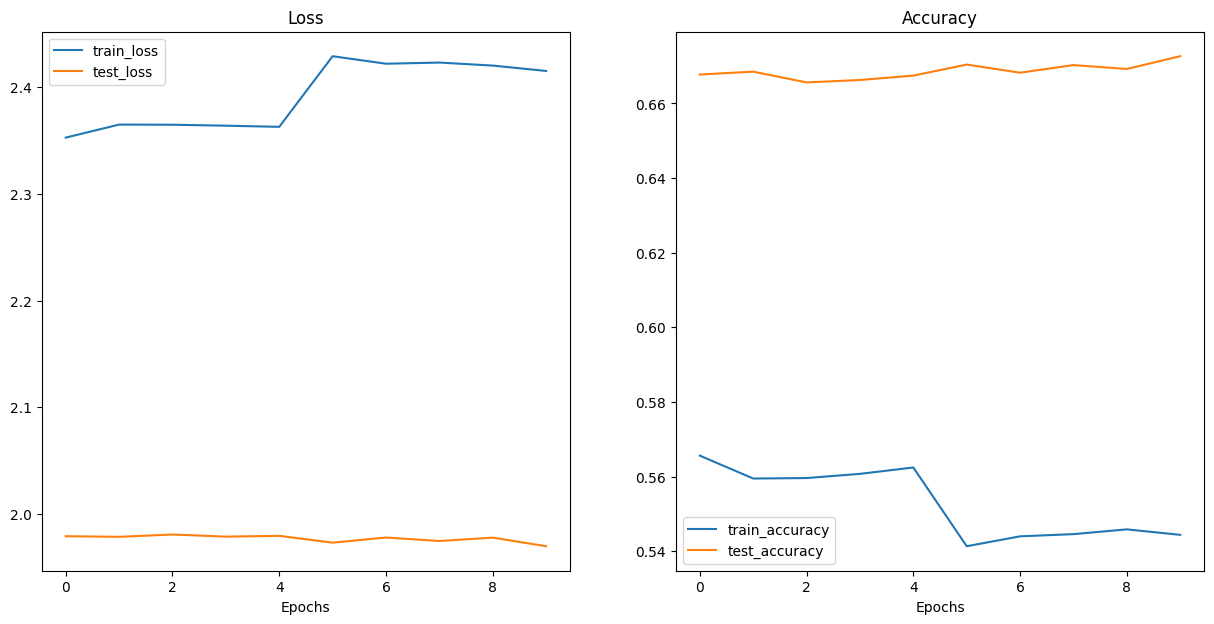

In [96]:
from helper_functions import plot_loss_curves
plot_loss_curves(effnetb2_food101_results)

In [97]:
from going_modular.going_modular import utils

# Create a model path
effnetb2_food101_model_path = "09_pretrained_effnetb2_feature_extractor_food101_100_percent_data_15_epochs_256_batch_size.pth"

# Save FoodVision Big model
utils.save_model(model=effnetb2_food101,
                 target_dir="models/",
                 model_name=effnetb2_food101_model_path)

[INFO] Saving model to: models\09_pretrained_effnetb2_feature_extractor_food101_100_percent_data_15_epochs_256_batch_size.pth


Since, we have 101k images for training, we will attempt to unfreeze the last layer of the effnetb2 model before the classifier to see if that yields better results

## 13. Training more layers of EffNetB2 

### 13.1 Update existing create_effnetb2_model

In [104]:
import helper_functions
def create_effnetb2_model(num_classes:int=3, # dfault output classes = 3 (pizza, steak, sushi)
                          seed:int=42):
  """Returns transforms and classes for an effnetb2 model with default weights
  Args:
  num_classes (int) - number of classes in the model
  seed (int) - random seed to initialize the trainable layers with"""

  helper_functions.set_seeds(42)

  # 1. Setup pretrained EffnetB3  with weights
  weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
  effnetb2_model = torchvision.models.efficientnet_b2(weights=weights)

  # 2. Get EffNetB2 transforms
  effnetb2_transforms = weights.transforms()

  # 3. Freeze all layers in base model
  for param in effnetb2_model.features.parameters():
    param.requires_grad=False

  # 4. Unfreeze features[8] layer
  for param in effnetb2_model.features[8].parameters():
      param.requires_grad=True

  # 5 . Change classifier head with random seed for reproducibility
  torch.manual_seed(seed)
  effnetb2_model.classifier = nn.Sequential(
      nn.Dropout(p=0.3, inplace=True),
      nn.Linear(in_features=1408,
                out_features=num_classes)
  )
  return effnetb2_model, effnetb2_transforms

In [130]:
#Create Food101 model and transforms
effnetb2_food101, effnetb2_transforms = create_effnetb2_model(num_classes=101)

# Unfreeze features[8] layer
for param in effnetb2_food101.features[8].parameters():
    param.requires_grad=True

In [131]:
summary(model=effnetb2_food101,
        col_width=20,
        input_size=(1,3,224,224),
        col_names=["input_size","output_size", "num_params", "trainable"],
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 101]             --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1408, 7, 7]      --                   Partial
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1,

### 13.2 Experimenting with batch size of 128

In [118]:
from torch.utils.data import DataLoader
BATCH_SIZE=128
NUM_WORKERS=1 # Setting a positive value allows pytorch to use more cpu where possible

In [119]:
train_dataloader_food101 = DataLoader(dataset=train_data,
                                      batch_size=BATCH_SIZE,
                                      shuffle=True,
                                      num_workers=NUM_WORKERS)
test_dataloader_food101 = DataLoader(dataset=test_data,
                                     batch_size=BATCH_SIZE,
                                     shuffle=False,
                                     num_workers=NUM_WORKERS)

In [120]:
len(train_dataloader_food101), len(test_dataloader_food101)

(592, 198)

In [132]:
# Loss function
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

# Optimizer
optimizer = torch.optim.Adam(params=effnetb2_food101.parameters(),
                             lr=1e-3)

In [133]:
device

device(type='cuda')

In [136]:
effnetb2_food101.load_state_dict(
    torch.load("models/09_pretrained_effnetb2_food101_1_unfrozen_backbone_100_percent_data_10_epochs_128_batch_size.pth")
)

<All keys matched successfully>

In [137]:
from going_modular.going_modular import engine

helper_functions.set_seeds()
effnetb2_food101_1_unfrozen_backbone_results = engine.train(model=effnetb2_food101,
                                                            train_dataloader=train_dataloader_food101,
                                                            test_dataloader=test_dataloader_food101,
                                                            optimizer=optimizer,
                                                            loss_fn=loss_fn,
                                                            epochs=5,
                                                            device=device)

 20%|██        | 1/5 [17:27<1:09:51, 1047.90s/it]

Epoch: 1 | train_loss: 1.8329 | train_acc: 0.7224 | test_loss: 1.7085 | test_acc: 0.7534


 40%|████      | 2/5 [34:40<51:57, 1039.01s/it]  

Epoch: 2 | train_loss: 1.8033 | train_acc: 0.7326 | test_loss: 1.7112 | test_acc: 0.7526


 60%|██████    | 3/5 [53:28<35:58, 1079.46s/it]

Epoch: 3 | train_loss: 1.7924 | train_acc: 0.7364 | test_loss: 1.7103 | test_acc: 0.7560


 80%|████████  | 4/5 [1:11:33<18:01, 1081.77s/it]

Epoch: 4 | train_loss: 1.7794 | train_acc: 0.7439 | test_loss: 1.7069 | test_acc: 0.7529


100%|██████████| 5/5 [1:29:25<00:00, 1073.16s/it]

Epoch: 5 | train_loss: 1.7650 | train_acc: 0.7473 | test_loss: 1.7091 | test_acc: 0.7553


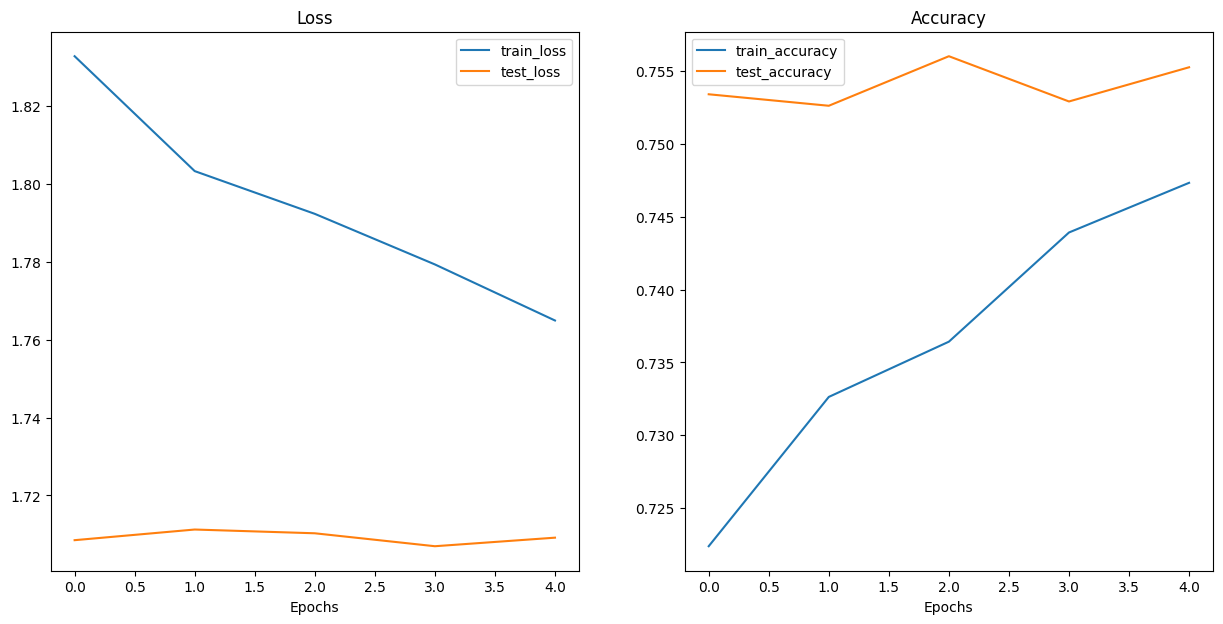

In [138]:
from helper_functions import plot_loss_curves
plot_loss_curves(effnetb2_food101_1_unfrozen_backbone_results)

In [139]:
from going_modular.going_modular import utils

# Create a model path
effnetb2_food101_model_path = "09_pretrained_effnetb2_food101_1_unfrozen_backbone_100_percent_data_15_epochs_128_batch_size.pth"

# Save FoodVision Big model
utils.save_model(model=effnetb2_food101,
                 target_dir="models/",
                 model_name=effnetb2_food101_model_path)

[INFO] Saving model to: models\09_pretrained_effnetb2_food101_1_unfrozen_backbone_100_percent_data_15_epochs_128_batch_size.pth


### 13.4 Unfreezing layer 7

In [142]:
#Create Food101 model and transforms
effnetb2_food101, effnetb2_transforms = create_effnetb2_model(num_classes=101)

# Unfreeze features[8] layer
for param in effnetb2_food101.features[8].parameters():
    param.requires_grad=True

for param in effnetb2_food101.features[7].parameters():
    param.requires_grad=True

In [143]:
# Loss function
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

# Optimizer
optimizer = torch.optim.Adam(params=effnetb2_food101.parameters(),
                             lr=1e-3)

In [144]:
from going_modular.going_modular import engine

helper_functions.set_seeds()
effnetb2_food101_2_unfrozen_backbone_results = engine.train(model=effnetb2_food101,
                                                            train_dataloader=train_dataloader_food101,
                                                            test_dataloader=test_dataloader_food101,
                                                            optimizer=optimizer,
                                                            loss_fn=loss_fn,
                                                            epochs=15,
                                                            device=device)

  7%|▋         | 1/15 [17:52<4:10:16, 1072.60s/it]

Epoch: 1 | train_loss: 2.3509 | train_acc: 0.5567 | test_loss: 1.6077 | test_acc: 0.7631


 13%|█▎        | 2/15 [34:55<3:46:05, 1043.51s/it]

Epoch: 2 | train_loss: 1.8832 | train_acc: 0.6824 | test_loss: 1.4928 | test_acc: 0.7966


 20%|██        | 3/15 [52:06<3:27:31, 1037.61s/it]

...

Epoch: 10 | train_loss: 1.3782 | train_acc: 0.8399 | test_loss: 1.3613 | test_acc: 0.8298


 73%|███████▎  | 11/15 [3:17:58<1:13:43, 1105.84s/it]

Epoch: 11 | train_loss: 1.3560 | train_acc: 0.8466 | test_loss: 1.3678 | test_acc: 0.8264


 73%|███████▎  | 11/15 [3:19:00<1:12:21, 1085.49s/it]


KeyboardInterrupt: 

In [145]:
from helper_functions import plot_loss_curves
plot_loss_curves(effnetb2_food101_2_unfrozen_backbone_results)

NameError: name 'effnetb2_food101_2_unfrozen_backbone_results' is not defined

In [146]:
from going_modular.going_modular import utils

# Create a model path
effnetb2_food101_model_path = "09_pretrained_effnetb2_food101_2_unfrozen_backbone_100_percent_data_11_epochs_128_batch_size.pth"

# Save FoodVision Big model
utils.save_model(model=effnetb2_food101,
                 target_dir="models/",
                 model_name=effnetb2_food101_model_path)

[INFO] Saving model to: models\09_pretrained_effnetb2_food101_2_unfrozen_backbone_100_percent_data_11_epochs_128_batch_size.pth


### 13.5 Testing with unfrozen layer 7 and batch size of 64
Testing with with batch size of 256 shows significantly worse performance. Testing to see if batch size of 64 makes a significant difference.

Performance is worse with a batch size of 64

In [153]:
from torch.utils.data import DataLoader
BATCH_SIZE=64
NUM_WORKERS=1 # Setting a positive value allows pytorch to use more cpu where possible

In [155]:
train_dataloader_food101_64_batch_size = DataLoader(dataset=train_data,
                                      batch_size=BATCH_SIZE,
                                      shuffle=True,
                                      num_workers=NUM_WORKERS)
test_dataloader_food101_64_batch_size = DataLoader(dataset=test_data,
                                     batch_size=BATCH_SIZE,
                                     shuffle=False,
                                     num_workers=NUM_WORKERS)

In [156]:
len(train_dataloader_food101_64_batch_size), len(test_dataloader_food101_64_batch_size)

(1184, 395)

In [157]:
#Create Food101 model and transforms
effnetb2_food101, effnetb2_transforms = create_effnetb2_model(num_classes=101)

In [158]:
# Loss function
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

# Optimizer
optimizer = torch.optim.Adam(params=effnetb2_food101.parameters(),
                             lr=1e-3)

In [160]:
from going_modular.going_modular import engine

helper_functions.set_seeds()
effnetb2_food101_2_unfrozen_backbone_64_batch_size_results = engine.train(model=effnetb2_food101,
                                                            train_dataloader=train_dataloader_food101_64_batch_size,
                                                            test_dataloader=test_dataloader_food101_64_batch_size,
                                                            optimizer=optimizer,
                                                            loss_fn=loss_fn,
                                                            epochs=10,
                                                            device=device)

 10%|█         | 1/10 [18:03<2:42:32, 1083.65s/it]

Epoch: 1 | train_loss: 3.0372 | train_acc: 0.4022 | test_loss: 2.2162 | test_acc: 0.6041


 20%|██        | 2/10 [36:31<2:26:20, 1097.61s/it]

Epoch: 2 | train_loss: 2.6146 | train_acc: 0.4906 | test_loss: 2.1026 | test_acc: 0.6322


 30%|███       | 3/10 [54:34<2:07:17, 1091.11s/it]

...

Epoch: 7 | train_loss: 2.5111 | train_acc: 0.5191 | test_loss: 2.0190 | test_acc: 0.6548


 80%|████████  | 8/10 [2:22:02<35:09, 1054.57s/it]

Epoch: 8 | train_loss: 2.5030 | train_acc: 0.5235 | test_loss: 2.0203 | test_acc: 0.6567


 80%|████████  | 8/10 [2:40:07<40:01, 1200.88s/it]


KeyboardInterrupt: 

### 13.6 Unfreezing layer 6

In [161]:
#Create Food101 model and transforms
effnetb2_food101, effnetb2_transforms = create_effnetb2_model(num_classes=101)

# Unfreeze features[8] layer
layer_to_unfreeze = [6,7,8]
for layer in layer_to_unfreeze:
    for param in effnetb2_food101.features[layer].parameters():
        param.requires_grad=True

In [162]:
summary(model=effnetb2_food101,
        col_width=20,
        input_size=(1,3,224,224),
        col_names=["input_size","output_size", "num_params", "trainable"],
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 101]             --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1408, 7, 7]      --                   Partial
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1,

In [163]:
# Loss function
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

# Optimizer
optimizer = torch.optim.Adam(params=effnetb2_food101.parameters(),
                             lr=1e-3)

In [164]:
len(train_dataloader_food101), len(test_dataloader_food101)

(592, 198)

In [165]:
from going_modular.going_modular import engine

helper_functions.set_seeds()
effnetb2_food101_3_unfrozen_backbone_results = engine.train(model=effnetb2_food101,
                                                            train_dataloader=train_dataloader_food101,
                                                            test_dataloader=test_dataloader_food101,
                                                            optimizer=optimizer,
                                                            loss_fn=loss_fn,
                                                            epochs=15,
                                                            device=device)

  7%|▋         | 1/15 [18:43<4:22:14, 1123.86s/it]

Epoch: 1 | train_loss: 2.1842 | train_acc: 0.5993 | test_loss: 1.4722 | test_acc: 0.7957


 13%|█▎        | 2/15 [37:22<4:02:49, 1120.71s/it]

Epoch: 2 | train_loss: 1.6951 | train_acc: 0.7361 | test_loss: 1.3637 | test_acc: 0.8295


 20%|██        | 3/15 [56:21<3:45:49, 1129.13s/it]

...

Epoch: 13 | train_loss: 1.1433 | train_acc: 0.9045 | test_loss: 1.2556 | test_acc: 0.8577


 93%|█████████▎| 14/15 [4:06:45<17:15, 1035.22s/it]

Epoch: 14 | train_loss: 1.1332 | train_acc: 0.9073 | test_loss: 1.2589 | test_acc: 0.8553


100%|██████████| 15/15 [4:24:01<00:00, 1056.08s/it]

Epoch: 15 | train_loss: 1.1177 | train_acc: 0.9121 | test_loss: 1.2550 | test_acc: 0.8573


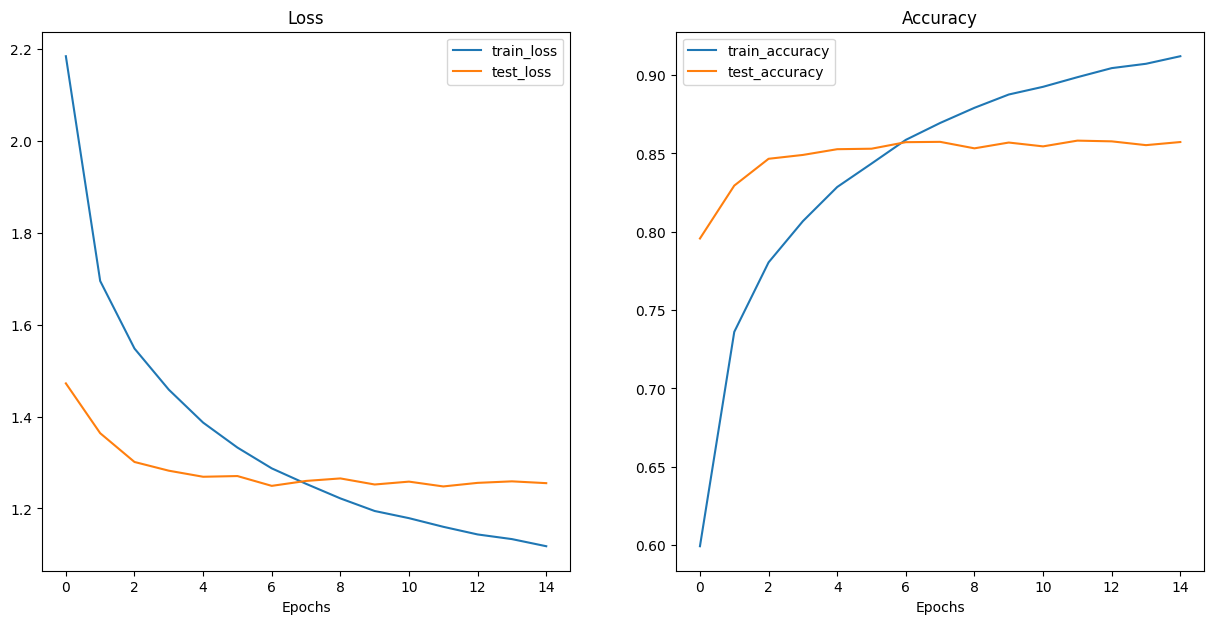

In [168]:
from helper_functions import plot_loss_curves
plot_loss_curves(effnetb2_food101_3_unfrozen_backbone_results)

When unfreezing bottom 3 backbone layers, best training results are achieved by epoch 7. Further training only causes overfitting.

In [169]:
from going_modular.going_modular import utils

# Create a model path
effnetb2_food101_model_path = "09_pretrained_effnetb2_food101_3_unfrozen_backbone_100_percent_data_15_epochs.pth"

# Save FoodVision Big model
utils.save_model(model=effnetb2_food101,
                 target_dir="models/",
                 model_name=effnetb2_food101_model_path)

[INFO] Saving model to: models\09_pretrained_effnetb2_food101_3_unfrozen_backbone_100_percent_data_15_epochs.pth


### 13.7 Unfreezing layer 5

In [170]:
#Create Food101 model and transforms
effnetb2_food101, effnetb2_transforms = create_effnetb2_model(num_classes=101)

# Unfreeze features[8] layer
layer_to_unfreeze = [5,6,7,8]
for layer in layer_to_unfreeze:
    for param in effnetb2_food101.features[layer].parameters():
        param.requires_grad=True


In [171]:
summary(model=effnetb2_food101,
        col_width=20,
        input_size=(1,3,224,224),
        col_names=["input_size","output_size", "num_params", "trainable"],
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 101]             --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1408, 7, 7]      --                   Partial
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1,

In [172]:
# Loss function
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

# Optimizer
optimizer = torch.optim.Adam(params=effnetb2_food101.parameters(),
                             lr=1e-3)

In [173]:
from going_modular.going_modular import engine

helper_functions.set_seeds()
effnetb2_food101_4_unfrozen_backbone_results = engine.train(model=effnetb2_food101,
                                                            train_dataloader=train_dataloader_food101,
                                                            test_dataloader=test_dataloader_food101,
                                                            optimizer=optimizer,
                                                            loss_fn=loss_fn,
                                                            epochs=10,
                                                            device=device)

 10%|█         | 1/10 [29:58<4:29:43, 1798.22s/it]

Epoch: 1 | train_loss: 2.1540 | train_acc: 0.6076 | test_loss: 1.4407 | test_acc: 0.8050


 20%|██        | 2/10 [1:03:09<4:14:53, 1911.75s/it]

Epoch: 2 | train_loss: 1.6647 | train_acc: 0.7440 | test_loss: 1.3587 | test_acc: 0.8285


 30%|███       | 3/10 [1:38:55<3:55:31, 2018.79s/it]

...

Epoch: 7 | train_loss: 1.2721 | train_acc: 0.8623 | test_loss: 1.2449 | test_acc: 0.8596


 80%|████████  | 8/10 [4:09:33<1:00:11, 1805.63s/it]

Epoch: 8 | train_loss: 1.2400 | train_acc: 0.8723 | test_loss: 1.2554 | test_acc: 0.8568


 80%|████████  | 8/10 [4:32:56<1:08:14, 2047.04s/it]


KeyboardInterrupt: 

In [174]:
from going_modular.going_modular import utils

# Create a model path
effnetb2_food101_model_path = "09_pretrained_effnetb2_food101_4_unfrozen_backbone_100_percent_data_8_epochs.pth"

# Save FoodVision Big model
utils.save_model(model=effnetb2_food101,
                 target_dir="models/",
                 model_name=effnetb2_food101_model_path)

[INFO] Saving model to: models\09_pretrained_effnetb2_food101_4_unfrozen_backbone_100_percent_data_8_epochs.pth


### 13.7 Unfreezing layer 4

In [176]:
#Create Food101 model and transforms
effnetb2_food101, effnetb2_transforms = create_effnetb2_model(num_classes=101)

# Unfreeze features[8] layer
layer_to_unfreeze = [4,5,6,7,8]
for layer in layer_to_unfreeze:
    for param in effnetb2_food101.features[layer].parameters():
        param.requires_grad=True


In [177]:
summary(model=effnetb2_food101,
        col_width=20,
        input_size=(1,3,224,224),
        col_names=["input_size","output_size", "num_params", "trainable"],
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 101]             --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1408, 7, 7]      --                   Partial
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1,

In [179]:
# Loss function
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

# Optimizer
optimizer = torch.optim.Adam(params=effnetb2_food101.parameters(),
                             lr=1e-3)

from going_modular.going_modular import engine

helper_functions.set_seeds()
effnetb2_food101_5_unfrozen_backbone_results = engine.train(model=effnetb2_food101,
                                                            train_dataloader=train_dataloader_food101,
                                                            test_dataloader=test_dataloader_food101,
                                                            optimizer=optimizer,
                                                            loss_fn=loss_fn,
                                                            epochs=10,
                                                            device=device)

 10%|█         | 1/10 [1:32:56<13:56:27, 5576.38s/it]

Epoch: 1 | train_loss: 2.1648 | train_acc: 0.6040 | test_loss: 1.4516 | test_acc: 0.8025


 20%|██        | 2/10 [2:55:45<11:35:51, 5218.98s/it]

Epoch: 2 | train_loss: 1.6671 | train_acc: 0.7430 | test_loss: 1.3542 | test_acc: 0.8275


 30%|███       | 3/10 [4:06:23<9:16:39, 4771.40s/it] 

...

Epoch: 8 | train_loss: 1.2393 | train_acc: 0.8723 | test_loss: 1.2470 | test_acc: 0.8574


 90%|█████████ | 9/10 [12:52:44<1:29:24, 5364.34s/it]

Epoch: 9 | train_loss: 1.2117 | train_acc: 0.8815 | test_loss: 1.2384 | test_acc: 0.8616


100%|██████████| 10/10 [14:21:36<00:00, 5169.70s/it] 

Epoch: 10 | train_loss: 1.1845 | train_acc: 0.8895 | test_loss: 1.2443 | test_acc: 0.8594


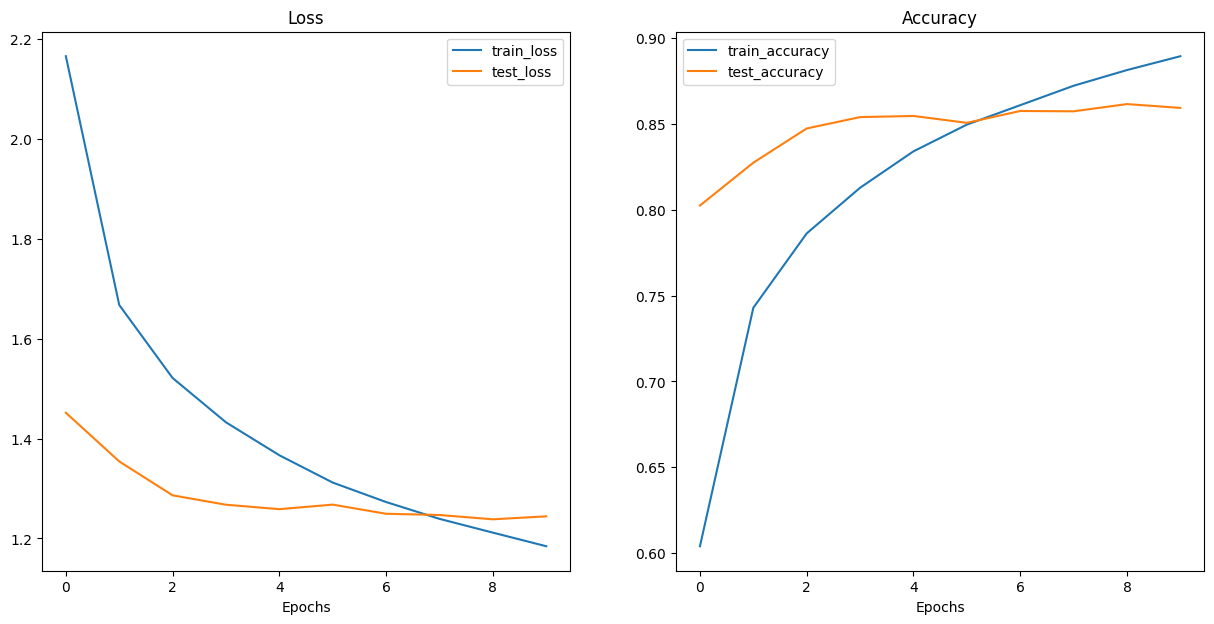

In [181]:
from helper_functions import plot_loss_curves
plot_loss_curves(effnetb2_food101_5_unfrozen_backbone_results)

In [182]:
from going_modular.going_modular import utils

# Create a model path
effnetb2_food101_model_path = "09_pretrained_effnetb2_food101_5_unfrozen_backbone_100_percent_data_10_epochs.pth"

# Save FoodVision Big model
utils.save_model(model=effnetb2_food101,
                 target_dir="models/",
                 model_name=effnetb2_food101_model_path)

[INFO] Saving model to: models\09_pretrained_effnetb2_food101_5_unfrozen_backbone_100_percent_data_10_epochs.pth
